In [ ]:
import tensorflow as tf
import numpy as np
import json
import os
from tensorflow.keras import Sequential, layers
from tensorflow.keras.models import load_model
from tensorflow.keras.layers import Dense, BatchNormalization, Dropout, GlobalAveragePooling2D, Conv2D, MaxPooling2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from pathlib import Path

# Congelar semilla para reproducibilidad
import random
seed_value = 67
random.seed(seed_value)
np.random.seed(seed_value)
tf.random.set_seed(seed_value)


In [2]:
# ============================================================
# 1) Parameters
# ============================================================

IMG_WIDTH, IMG_HEIGHT = 224, 224
BATCH_SIZE = 32
EPOCHS = 50

BASE_DIR = Path.cwd()

TRAIN_DATA_DIR = BASE_DIR / "Animals_Dataset_Splitted" / "train"
VALIDATION_DATA_DIR = BASE_DIR / "Animals_Dataset_Splitted" / "validation"
TEST_DATA_DIR = BASE_DIR / "Animals_Dataset_Splitted" / "test"


In [3]:
# ============================================================
# 2) Data Generators
# ============================================================

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1.0 / 255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=True
)

validation_generator = val_test_datagen.flow_from_directory(
    VALIDATION_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DATA_DIR,
    target_size=(IMG_WIDTH, IMG_HEIGHT),
    batch_size=BATCH_SIZE,
    class_mode="sparse",
    shuffle=False
)


Found 20938 images belonging to 10 classes.
Found 2614 images belonging to 10 classes.
Found 2627 images belonging to 10 classes.


In [4]:
# ============================================================
# 3) Class Mapping & Weights
# ============================================================

class_indices = train_generator.class_indices
index_to_class = {v: k for k, v in class_indices.items()}


# Guardar mapeo de clases
class_mapping_path = os.path.join(os.getcwd(), "mapeo_clases_CM.json")
with open(class_mapping_path, "w", encoding="utf-8") as f:
    json.dump({"class_indices": class_indices, "index_to_class": index_to_class}, f, indent=2)
print("Mapeo de clases guardado en:", class_mapping_path)

# Calcular class weights para compensar desbalance
num_classes = train_generator.num_classes

train_counts = {}
for class_name in class_indices:
    class_dir = os.path.join(TRAIN_DATA_DIR, class_name)
    train_counts[class_name] = len(os.listdir(class_dir))

total_train = sum(train_counts.values())

class_weight = {}
for class_name, class_index in class_indices.items():
    class_count = train_counts[class_name]
    class_weight[class_index] = total_train / (num_classes * class_count)

print("\nClass weights:")
for class_index, weight in class_weight.items():
    print(f"  {class_index} ({index_to_class[class_index]}): {weight:.4f}")


Mapeo de clases guardado en: C:\IA-FAC\mapeo_clases_CM.json
Class weights:
  0 (araña): 0.5430
  1 (ardilla): 1.4062
  2 (caballo): 0.9980
  3 (elefante): 1.8112
  4 (gallina): 0.8450
  5 (gato): 1.5696
  6 (mariposa): 1.2397
  7 (oveja): 1.4380
  8 (perro): 0.5383
  9 (vaca): 1.4034


In [5]:
# ============================================================
# 4) Build and Compile Custom Model
# ============================================================

# Nota: NO usamos Rescaling dentro del modelo porque ya aplicamos
# rescale=1./255 en el ImageDataGenerator.

model = Sequential([
    Conv2D(32, 3, padding="same", activation="relu", input_shape=(IMG_WIDTH, IMG_HEIGHT, 3)),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(64, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(128, 3, padding="same", activation="relu"),
    BatchNormalization(),
    MaxPooling2D(),

    Conv2D(256, 3, padding="same", activation="relu"),
    BatchNormalization(),

    GlobalAveragePooling2D(),

    Dense(256, activation="relu"),
    BatchNormalization(),
    Dropout(0.3),

    Dense(train_generator.num_classes, activation="softmax")
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


C:\IA-FAC\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 256)         │         295,168 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 256)                 │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 422,602 (1.61 MB)

 Trainable params: 422,602 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [6]:
# ============================================================
# 5) Callbacks
# ============================================================

checkpoint_path = os.path.join(os.getcwd(), "mejor_modelo_CM.keras")

early_stopping = EarlyStopping(
    monitor="val_accuracy",
    mode="max",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    checkpoint_path,
    monitor="val_accuracy",
    mode="max",
    save_best_only=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

callbacks = [early_stopping, checkpoint, reduce_lr]


In [7]:
# ============================================================
# 6) Training
# ============================================================

history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=EPOCHS,
    callbacks=callbacks,
    class_weight=class_weight
)


Epoch 1/50
Epoch 1: val_accuracy improved from None to 0.18477, saving model to C:\IA-FAC\mejor_modelo_CM.keras
Epoch 1: finished saving model to C:\IA-FAC\mejor_modelo_CM.keras
655/655 ━━━━━━━━━━━━━━━━━━━━ 524s 797ms/step - accuracy: 0.1509 - loss: 2.2445 - val_accuracy: 0.1848 - val_loss: 2.2162 - learning_rate: 1.0000e-04
Epoch 2/50
Epoch 2: val_accuracy did not improve from 0.18477
655/655 ━━━━━━━━━━━━━━━━━━━━ 479s 731ms/step - accuracy: 0.1843 - loss: 2.1464 - val_accuracy: 0.1783 - val_loss: 2.1704 - learning_rate: 1.0000e-04
Epoch 3/50
Epoch 3: val_accuracy improved from 0.18477 to 0.20352, saving model to C:\IA-FAC\mejor_modelo_CM.keras
Epoch 3: finished saving model to C:\IA-FAC\mejor_modelo_CM.keras
655/655 ━━━━━━━━━━━━━━━━━━━━ 499s 762ms/step - accuracy: 0.1994 - loss: 2.0913 - val_accuracy: 0.2035 - val_loss: 2.1599 - learning_rate: 1.0000e-04
Epoch 4/50
Epoch 4: val_accuracy improved from 0.20352 to 0.22188, saving model to C:\IA-FAC\mejor_modelo_CM.keras
Epoch 4: finished

In [8]:
# ============================================================
# 7) Save Final Model
# ============================================================

final_model_path = os.path.join(os.getcwd(), "modelo_final_CM.keras")

model.save(final_model_path)

print("Modelo final guardado en:", final_model_path)
print("Mejor modelo guardado en:", checkpoint_path)
print("Mapeo de clases guardado en:", class_mapping_path)


Modelo final guardado en: C:\IA-FAC\modelo_final_CM.keras
Mejor modelo guardado en: C:\IA-FAC\mejor_modelo_CM.keras
Mapeo de clases guardado en: C:\IA-FAC\mapeo_clases_CM.json


In [9]:
# ============================================================
# 8) Evaluation on Test Set
# ============================================================

best_model = load_model(checkpoint_path)

test_loss, test_acc = best_model.evaluate(test_generator)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")


Test Loss: 1.6461
Test Accuracy: 0.4111


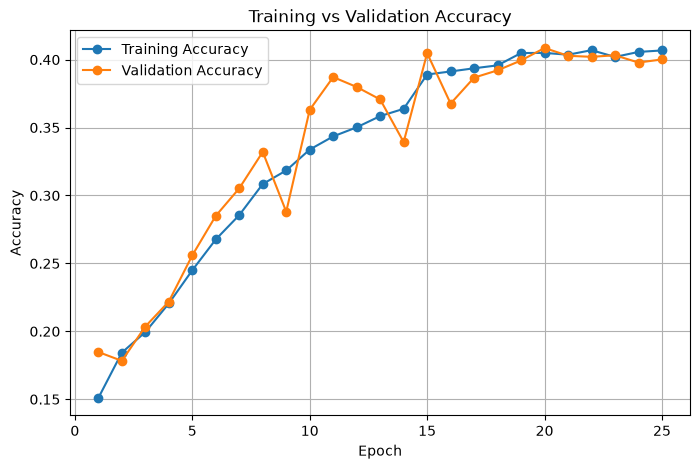

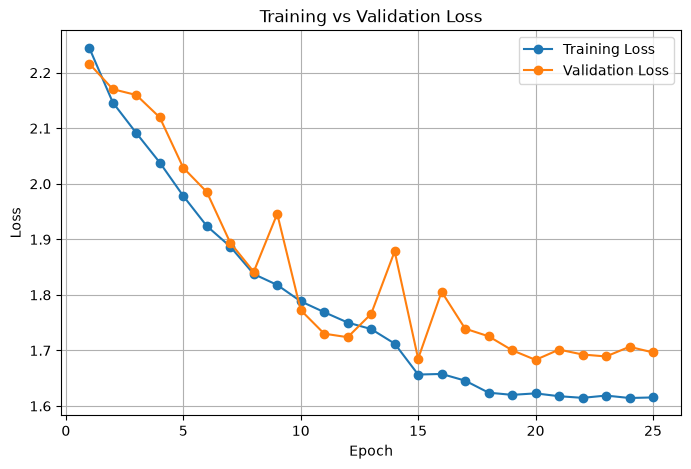

In [10]:
# ============================================================
# 9) Accuracy and Loss Graphs
# ============================================================

accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(accuracy) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, accuracy, marker="o", label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, marker="o", label="Validation Accuracy")
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs_range, loss, marker="o", label="Training Loss")
plt.plot(epochs_range, val_loss, marker="o", label="Validation Loss")
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()


<Figure size 1000x1000 with 0 Axes>

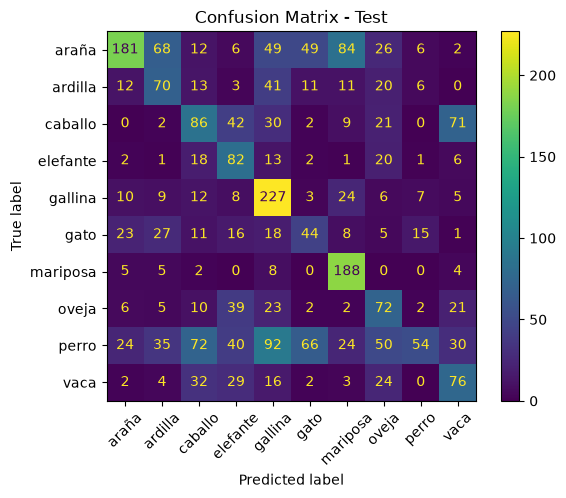

Classification Report:
              precision    recall  f1-score   support
       araña       0.68      0.37      0.48       483
     ardilla       0.31      0.37      0.34       187
     caballo       0.32      0.33      0.32       263
    elefante       0.31      0.56      0.40       146
     gallina       0.44      0.73      0.55       311
        gato       0.24      0.26      0.25       168
    mariposa       0.53      0.89      0.66       212
       oveja       0.30      0.40      0.34       182
       perro       0.59      0.11      0.19       487
        vaca       0.35      0.40      0.38       188
    accuracy                           0.41      2627
   macro avg       0.41      0.44      0.39      2627
weighted avg       0.46      0.41      0.39      2627


In [11]:
# ============================================================
# 10) Confusion Matrix and Classification Report
# ============================================================

test_generator.reset()

pred_probs = best_model.predict(test_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes

labels = list(range(train_generator.num_classes))
target_names = [index_to_class[i] for i in labels]

print("Classification Report:")
print(classification_report(y_true, y_pred, labels=labels, target_names=target_names))

cm = confusion_matrix(y_true, y_pred, labels=labels)

plt.figure(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_names)
disp.plot(xticks_rotation=45, values_format="d")
plt.title("Confusion Matrix - Test")
plt.show()


In [12]:
# ============================================================
# 11) Individual Image Prediction
# ============================================================

from tensorflow.keras.preprocessing import image

def predict_image(img_path, model_path=checkpoint_path):
    loaded_model = load_model(model_path)

    img = image.load_img(img_path, target_size=(IMG_WIDTH, IMG_HEIGHT))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array = img_array / 255.0  # Same rescaling as training

    pred = loaded_model.predict(img_array)
    pred_index = int(np.argmax(pred, axis=1)[0])
    confidence = float(np.max(pred))

    class_name = index_to_class[pred_index]

    print(f"Predicted class: {class_name} ({class_name})")
    print(f"Confidence: {confidence:.4f}")

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"{class_name} - {confidence:.2%}")
    plt.show()

    return class_name, confidence

# Example usage:
# predict_image("Animals_Dataset_Splitted/test/gato/some_image.jpeg")
